In [60]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, hl_sac

In [61]:
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [62]:
action_low = env.action_space.low[:4]
action_high = env.action_space.high[:4]
action_bounds = (action_low, action_high)

In [63]:
params = SB3_PARAMS
hidden_sizes = [128, 128]
# params["lr_critic"] = 1e-3

In [64]:
random_seed = 0

In [65]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [66]:
# sac = hl_sac(hidden_sizes=hidden_sizes, action_bounds=action_bounds, **params)
sac = from_dict(hidden_sizes=hidden_sizes, action_bounds=action_bounds, **params)

In [67]:
agent = sac
agent_name = "HLSAC"

In [68]:
filepath = f"./defense/{agent_name}-{env_name}-{random_seed}"

In [69]:
# state = torch.load(f'{filepath}-{3639}.pth')
# agent.restore_state(state)

In [70]:
scaling = np.asarray([ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4.0 ,4.0])

In [71]:
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [72]:
for i in range(5):
    o, info = env.reset()
    # o /= scaling
    env.render()
    
    for _ in range(1000):
        env.render()
        a1 = agent.act(o, noise_scale=0.) # np.random.uniform(-1,1,4)
        # a1 = np.random.uniform(-1, 1, 4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        # obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

In [73]:
env.close()

In [74]:
losses = []
rewards = []
i_episode = 0
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [75]:
max_timesteps = 1000
new_episodes = 2000
log_interval = 10
train_interval = 10

In [76]:
for i in range(new_episodes):
    total_reward = 0
    o, info = env.reset()
    # o /= scaling
    # env.render()

    for j in range(max_timesteps):
        # env.render()
        a1 = agent.act(o) # np.random.uniform(-1,1,4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        # obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        if j % train_interval == 0:
            loss = agent.train()
            losses.append(loss)
        total_reward += r
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

    i_episode += 1
    
    rewards.append(total_reward)
    if (i_episode+1) % log_interval == 0:
        print(i_episode+1, np.mean(rewards[-10:]))

10 -1.7369825357939201
20 -6.84002639297802
30 -7.751873939657591
40 -5.015507779005697
50 -5.658148279560608
60 -4.571761620189951
70 -10.000520068860691
80 -7.256427056574002
90 -5.3177051992019555
100 -3.7191510106146155
110 -6.037897521582382
120 -10.943790328894625
130 -1.7128685946726123
140 -8.226052836450767
150 -5.543487532405272
160 -7.563958370533245
170 -7.14089963440116
180 -4.16646160746761
190 -5.7178164430195295
200 -2.7158535432293722
210 -11.468436335870692
220 -9.192512821283742
230 -7.372517413570577
240 -3.8613189309991895
250 -3.379541676514046
260 -8.045959247880827
270 -4.574966750132854
280 -8.280389089250168
290 1.7536741773837434
300 -9.441051420809227
310 -2.1870523658923573
320 -6.373790237863358
330 -9.464171538836755
340 -7.799220836721439
350 -11.091962300688623
360 -6.6450144076676825
370 -12.364021880716184
380 -1.3854272625040858
390 -12.217519792551538
400 -7.093618623711786
410 -2.3907558656380226
420 -5.904439816179446
430 -3.4853988651221215
440 -

KeyboardInterrupt: 

In [110]:
print("########## Saving a checkpoint... ##########")
torch.save(agent.state(), f'{filepath}-{i_episode}.pth')

########## Saving a checkpoint... ##########


In [111]:
from sac.utils import save_statistics
save_statistics(filepath, rewards, [], losses)

In [49]:
plot_path = "defense"

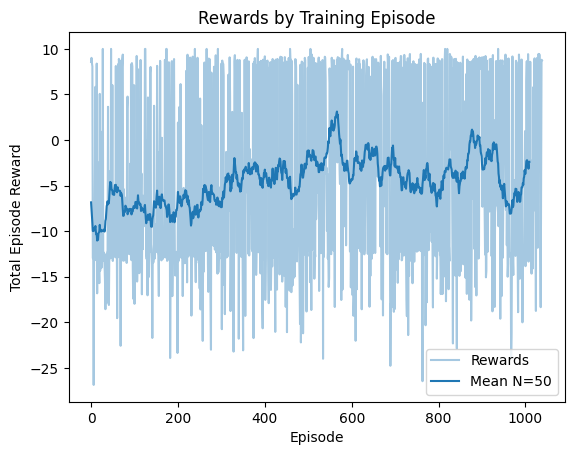

In [50]:
plot_rewards(rewards, plot_path, 30)

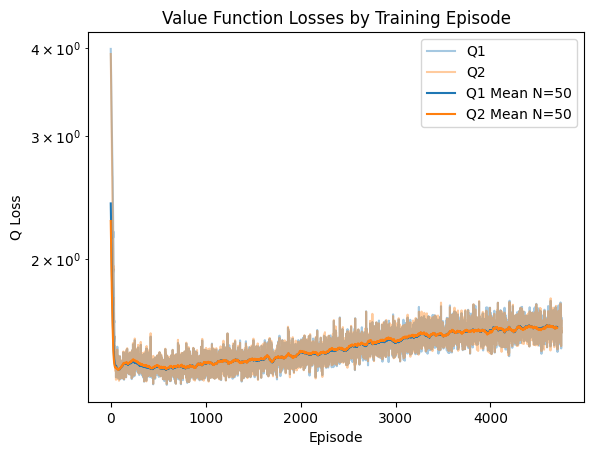

In [51]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

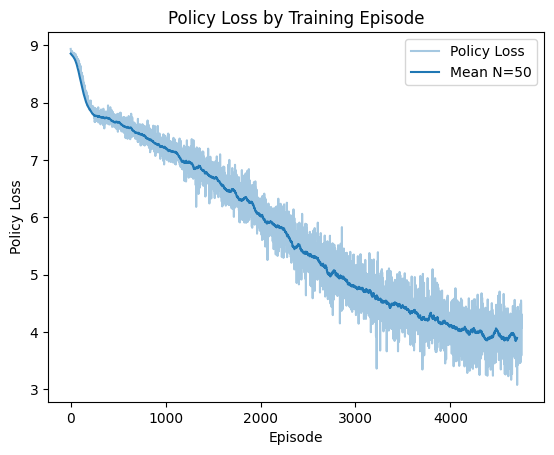

In [52]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

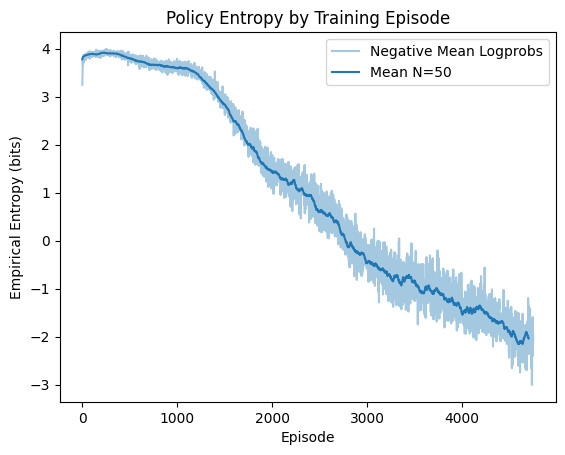

In [53]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)